# Maximum Likelihood (MLE) and Maximum A Posteriori (MAP)

**Goal:** Understand how to estimate parameters from data, and how MAP connects to regularization.

**Reference:** Mathematics for ML - Chapter 8.3, 6.6

## The Problem

We observe data $\mathcal{D} = \{x_1, x_2, \ldots, x_N\}$ drawn from a distribution with **unknown parameter** $\theta$.

**Goal:** estimate $\theta$ from the data.

Two main approaches:
1. **MLE (frequentist):** find $\theta$ that makes the data most likely
2. **MAP (Bayesian):** find the most probable $\theta$ given the data and a prior

**Why it matters for ML:**
- Training a model = estimating its parameters
- Loss functions come from likelihoods
- Regularization comes from priors

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

## Maximum Likelihood Estimation (MLE)

**Likelihood:** probability of the data as a function of $\theta$:

$$L(\theta) = P(\mathcal{D} \mid \theta) = \prod_{i=1}^{N} p(x_i \mid \theta)$$

**Log-likelihood** (easier to optimize):

$$\ell(\theta) = \log L(\theta) = \sum_{i=1}^{N} \log p(x_i \mid \theta)$$

**MLE:**
$$\hat{\theta}_{\text{MLE}} = \arg\max_\theta \ell(\theta)$$

**Why log?** Because $\log$ is monotonic, so the argmax is the same, but sums are easier than products.

In [2]:
np.random.seed(42)

# True parameters
mu_true = 3.0
sigma_true = 2.0

# Generate data
data = np.random.randn(1000) * sigma_true + mu_true

# MLE for Gaussian:
#   mu_hat = (1/N) * sum(x_i)
#   sigma^2_hat = (1/N) * sum((x_i - mu_hat)^2)

mu_mle = data.mean()
sigma2_mle = ((data - mu_mle) ** 2).mean()

print(f"True mu:      {mu_true}")
print(f"MLE mu:       {mu_mle:.4f}")
print()
print(f"True sigma^2: {sigma_true ** 2}")
print(f"MLE sigma^2:  {sigma2_mle:.4f}")

True mu:      3.0
MLE mu:       3.0387

True sigma^2: 4.0
MLE sigma^2:  3.8316


## Maximum A Posteriori (MAP)

**Bayes' theorem:**
$$P(\theta \mid \mathcal{D}) = \frac{P(\mathcal{D} \mid \theta) \cdot P(\theta)}{P(\mathcal{D})}$$

**MAP:** choose $\theta$ that maximizes the posterior:

$$\hat{\theta}_{\text{MAP}} = \arg\max_\theta P(\theta \mid \mathcal{D}) = \arg\max_\theta \left[ \log P(\mathcal{D} \mid \theta) + \log P(\theta) \right]$$

**Note:**
- $P(\mathcal{D})$ doesn't depend on $\theta$, so it's dropped
- First term = likelihood (same as MLE)
- Second term = **prior** $P(\theta)$ — this is what MLE lacks

**Key insight:**
$$\text{MAP} = \text{MLE} + \text{prior}$$

In [3]:
mu_0 = 0.0        # prior mean
sigma_0 = 1.0     # prior std

N = len(data)
sigma = sigma_true  

x_bar = data.mean()
mu_map = (sigma_0**2 * N * x_bar + sigma**2 * mu_0) / (sigma_0**2 * N + sigma**2)

print(f"MLE mu:      {mu_mle:.4f}")
print(f"MAP mu:      {mu_map:.4f}")
print(f"Prior mean:  {mu_0}")
print()
print("MAP shrinks MLE toward the prior mean.")

MLE mu:      3.0387
MAP mu:      3.0266
Prior mean:  0.0

MAP shrinks MLE toward the prior mean.


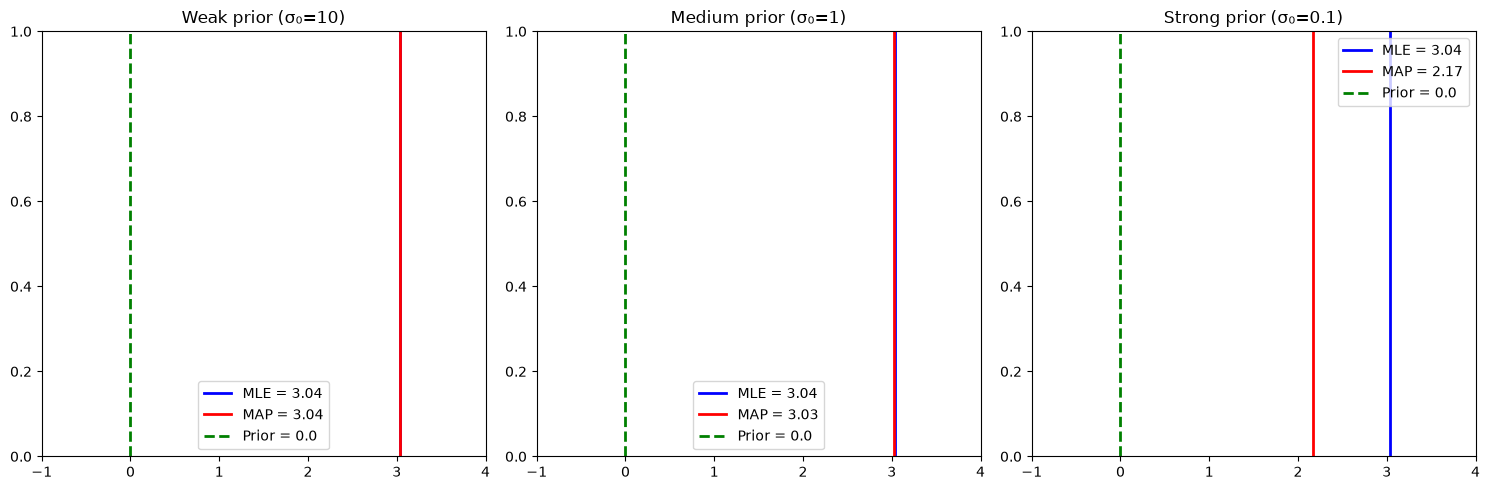

In [4]:
# Show how MAP changes with different priors and different amounts of data

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

priors = [
    ("Weak prior (σ₀=10)", 0.0, 10.0),
    ("Medium prior (σ₀=1)", 0.0, 1.0),
    ("Strong prior (σ₀=0.1)", 0.0, 0.1),
]

x_bar = data.mean()
sigma = sigma_true

for ax, (title, mu_0, sigma_0) in zip(axes, priors):
    mu_map = (sigma_0**2 * N * x_bar + sigma**2 * mu_0) / (sigma_0**2 * N + sigma**2)
    ax.axvline(mu_mle, color='blue', label=f'MLE = {mu_mle:.2f}', linewidth=2)
    ax.axvline(mu_map, color='red', label=f'MAP = {mu_map:.2f}', linewidth=2)
    ax.axvline(mu_0, color='green', linestyle='--', label=f'Prior = {mu_0}', linewidth=2)
    ax.set_title(title)
    ax.legend()
    ax.set_xlim(-1, 4)

plt.tight_layout()
plt.show()

## MAP = Regularization

This is one of the most important connections in ML.

**Linear regression MLE:**
$$\hat{\theta}_{\text{MLE}} = \arg\min_\theta \sum_i (y_i - \theta^T x_i)^2$$

**Linear regression MAP with Gaussian prior** $P(\theta) = \mathcal{N}(0, \lambda^{-1} I)$:

$$\hat{\theta}_{\text{MAP}} = \arg\min_\theta \left[ \sum_i (y_i - \theta^T x_i)^2 + \lambda \|\theta\|_2^2 \right]$$

→ This is **Ridge regression**!

**With Laplace prior** $P(\theta) \propto \exp(-\lambda |\theta|)$:

$$\hat{\theta}_{\text{MAP}} = \arg\min_\theta \left[ \sum_i (y_i - \theta^T x_i)^2 + \lambda \|\theta\|_1 \right]$$

→ This is **Lasso**!

| Prior | Penalty | Name |
|-------|---------|------|
| Gaussian | L2 | Ridge |
| Laplace | L1 | Lasso |
| Uniform | None | MLE |

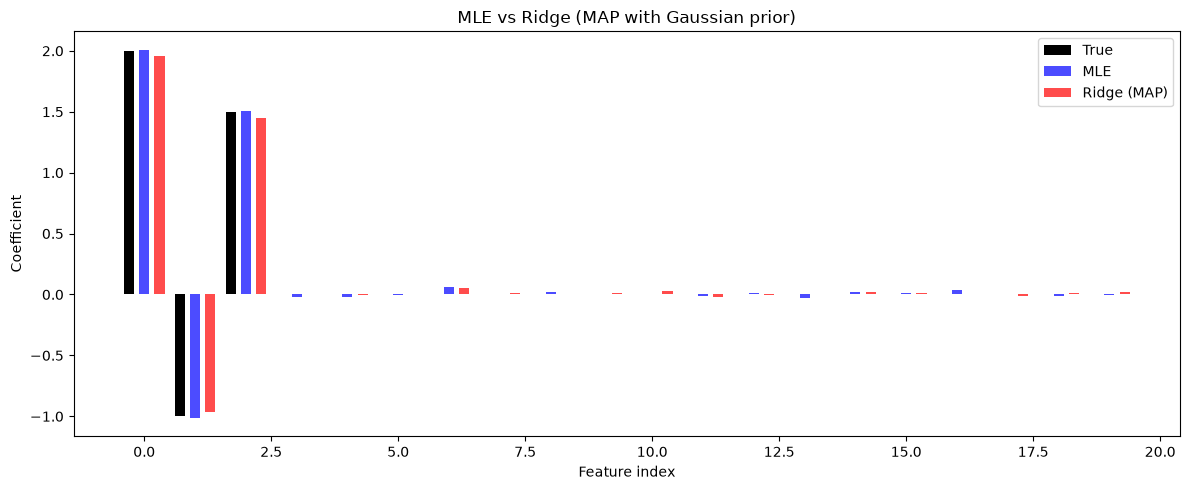

||theta_mle||^2 = 7.3455
||theta_ridge||^2 = 6.8733
Ridge shrinks coefficients toward zero.


In [5]:
# Simulate linear regression with sparse true coefficients
np.random.seed(0)

N, d = 50, 20
X = np.random.randn(N, d)
theta_true = np.zeros(d)
theta_true[:3] = [2, -1, 1.5]   # only 3 nonzero
y = X @ theta_true + 0.1 * np.random.randn(N)

# MLE (ordinary least squares)
theta_mle = np.linalg.lstsq(X, y, rcond=None)[0]

# Ridge (L2 penalty)
def ridge(X, y, lam):
    d = X.shape[1]
    return np.linalg.solve(X.T @ X + lam * np.eye(d), X.T @ y)

theta_ridge = ridge(X, y, lam=1.0)

# Compare
fig, ax = plt.subplots(figsize=(12, 5))
x_idx = np.arange(d)
ax.bar(x_idx - 0.3, theta_true, width=0.2, label='True', color='black')
ax.bar(x_idx, theta_mle, width=0.2, label='MLE', color='blue', alpha=0.7)
ax.bar(x_idx + 0.3, theta_ridge, width=0.2, label='Ridge (MAP)', color='red', alpha=0.7)
ax.set_xlabel('Feature index')
ax.set_ylabel('Coefficient')
ax.set_title('MLE vs Ridge (MAP with Gaussian prior)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"||theta_mle||^2 = {np.sum(theta_mle**2):.4f}")
print(f"||theta_ridge||^2 = {np.sum(theta_ridge**2):.4f}")
print("Ridge shrinks coefficients toward zero.")